In [114]:
import numpy as np

from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current

from pybatteryse.statespace import StateSpace
from pybatteryse.filters import ExtendedKalmanFilter
from pybatteryse.plotter import plot_time_vs_parameter
from pybatteryse.utilities import print_statespace_equations

from data import helper

### Load identified model and test dataset

We have included multiple datasets representing drive-cycle data obtained from a 2.85 Ah NMC cell at different stages in its life, i.e., when the battery capacity is (i) 98%, (ii) 94%, and (iii) 85% of its rated capacity value.

In [115]:
model = load_model_from_file('data/nmc_with_ageing/capacity_98%/model_n,l=1,1.npy')
dataset = helper.load_npy_datasets(f'data/nmc_with_ageing/capacity_98%/drive_cycle_data.npy')

In [116]:
time_values = dataset['time_values'] / 3600
current_values = dataset['current_values']
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']

# We use correct initial SOC here.
initial_soc = invert_voltage_function(model.emf_function, voltage_values[0])

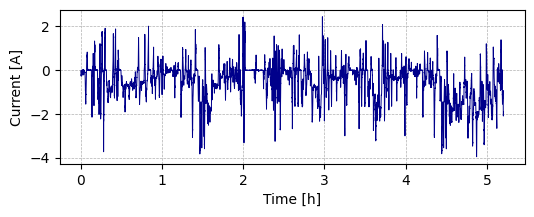

In [117]:
plot_time_vs_current([(time_values, current_values)], units=('h', 'A'), colors=['darkblue'])

### Select model parameters

In principle, we do not know the model parameters of an unseen test cell. Accordingly, we can choose parameters using the values learned from the training cells. Essentially, we identified models for a collection of training cells, and calculated mean parameter values. We expect that most of these values would be the same for the unseen test cell.

In [118]:
# These parameters are identified by doing model identification for the test cell,
# and are chosen as reference.
true_model_parameters = model.model_estimate
true_battery_capacity = model.battery_capacity

# These are the mean values learned (user-provided values). Obtaining these values
# is out of the scope of this package.
model.model_estimate = [0.3243599634590211, 0.0016222701892434582, # <--- y_{k-1}
                        0.017607961202546644, 0.0003176717201218238, -0.0011110135791564163, # <--- u_k
                        -0.014322342426930664, -0.00020490084950971742, -0.001558389175651483] # <--- u_{k-1}

### Load state-space representation

While we keep most parameters fixed, we select some parameters that capture ageing-dependent behaviour. We call them free parameters, and estimate them along with battery capacity and other states. In this case, the parameters are $\theta_3$ and $\theta_6$.

In [119]:
ss_representation = StateSpace(model, state_components=['s', 'overpotentials', 'theta_3', 'theta_6', 'capacity'])

For clarity, we print the employed state-space model structure.

In [120]:
print_statespace_equations(ss_representation)

╭────────────── State-space equations ──────────────╮
│                                                   │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k             │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k  │
│                                                   │
│ where                                             │
│                                                   │
│ x_k = [s_k, x_1,k, θ_3,k, θ_6,k, ℚ_k]   (dim = 5) │
│ p_k = [s_k, i_k, T_k]                             │
│ u_k = i_k                                         │
│                                                   │
│          ┌                           ┐            │
│          │ 1 ¦         0 ¦ 0 ¦ 0 ¦ 0 │            │
│          │ --+-----------+---+---+-- │            │
│          │ 0 ¦ -a_1(p_k) ¦ 0 ¦ 0 ¦ 0 │            │
│          │ --+-----------+---+---+-- │            │
│ A(p_k) = │ 0 ¦         0 ¦ 1 ¦ 0 ¦ 0 │            │
│          │ --+-----------+---+---+-- │            │
│          │ 0 ¦         0 ¦ 0 ¦ 1 ¦ 0 │            │
│          │ --+-----------+---+---+-- │            │
│          │ 0 ¦         0 ¦ 0 ¦ 0 ¦ 1 │            │
│          └                           ┘            │
│                                                   │
│          ┌                              ┐         │
│          │                     Δt / ℚ_k │         │
│          │ ---------------------------- │         │
│          │ b_1(p_k) - a_1(p_k)·b_0(p_k) │         │
│          │ ---------------------------- │         │
│ B(p_k) = │                            0 │         │
│          │ ---------------------------- │         │
│          │                            0 │         │
│          │ ---------------------------- │         │
│          │                            0 │         │
│          └                              ┘         │
│                                                   │
│     ┌                   ┐                         │
│ C = │ 0 ¦ 1 ¦ 0 ¦ 0 ¦ 0 │                         │
│     └                   ┘                         │
│                                                   │
│          ┌          ┐                             │
│ D(p_k) = │ b_0(p_k) │                             │
│          └          ┘                             │
╰───────────────────────────────────────────────────╯

### Load EKF and run it on the dataset

In [121]:
ekf = ExtendedKalmanFilter(statespace=ss_representation,
                           variance_eta_u=1e-3,
                           variance_eta_y_e=1e-3,
                           variance_eta_theta=1e-12,
                           variance_eta_capacity=0.1)

# Dataset with bad current values
dataset_for_model_estimation = {
    'current_values': current_values,
    'voltage_values': voltage_values,
    'temperature_values': temperature_values,
}

We can now run our EKF. We provide initial values for the free parameters equal to the mean values given above. However, these parameters are now freely estimated using the EKF.

In [122]:
# Set initial conditions
initial_state = np.array([ initial_soc, 0, 0.017607961202546644, -0.014322342426930664, 10300 ])
initial_covariance = np.zeros((len(initial_state), len(initial_state)))

state_estimates = ekf.run(
    dataset=dataset_for_model_estimation,
    initial_state=initial_state,
    initial_covariance=initial_covariance,
)

# Extract relevant trajectories
soc_est = state_estimates[:, 0]
theta_3_est = state_estimates[:, 2]
theta_6_est = state_estimates[:, 3]
capacity_est = state_estimates[:, 4]

EKF Progress: 100%|███████████████████████████████████████| 18739/18739 [00:13<00:00, 1433.55step/s]


We now compare the estimated parameter values with the "true" values that were estimated offline for the test cell using more informative identification datasets.

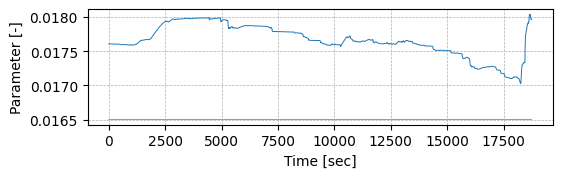

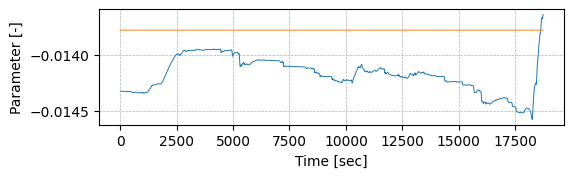

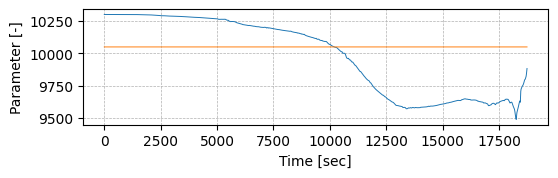

In [123]:
theta_3_true_value = true_model_parameters[2]
theta_6_true_value = true_model_parameters[5]
capacity_true_value = true_battery_capacity

#
plot_time_vs_parameter([(dataset['time_values'], theta_3_est),
                        (dataset['time_values'], [theta_3_true_value] * len(dataset['time_values']))], figsize=(6,1.5))
plot_time_vs_parameter([(dataset['time_values'], theta_6_est),
                        (dataset['time_values'], [theta_6_true_value] * len(dataset['time_values']))], figsize=(6,1.5))
plot_time_vs_parameter([(dataset['time_values'], capacity_est),
                        (dataset['time_values'], [capacity_true_value] * len(dataset['time_values']))], figsize=(6,1.5))